# Assignment of DSAIT4310 

September 13, 2026

Consider the processed ”SFHH” face-to-face contact network at a conference, which is given in the following format: each row ”$a\ b\ t$” denotes an undirected contact (a temporal link) between node $a$ and $b$ at time step $t$. This contact network is sampled/measured once every 20 seconds during a conference. Thus, each time step has a duration of 20s, which is though not relevant for our analysis in this assignment. We denote this temporal network as $G_{data}$.

**A.** 
Explore properties of network $G$ that is aggregated over all the $T = 3259$ steps. Specifically, the aggregated network $G$ is composed of all the nodes that have ever appeared in the dataset and any two nodes are connected by a link if they have at least a contact over the whole period $[1, T ]$.
Compute the following topological properties of $G$ in 1)-6) without considering the weight of any link and the link weight property in 7).

## Imports

1) What is the number of nodes $N$, the link density $p$ and standard deviation of the degree $\sqrt{Var[D]}$?

In [128]:
import pandas as pd
import numpy as np
import networkx as nx
from scipy.stats import binom
from IPython.display import Markdown

SEED = 42

df_data = pd.read_excel("G_data.xlsx")

G = nx.from_pandas_edgelist(df_data, source="node1", target="node2")

N = G.number_of_nodes()

E = G.number_of_edges()

p = nx.density(G)

degrees = np.array([d for node, d in G.degree()])

std_d = np.std(degrees)

# print(f"Number of Nodes N: {N}")
# print(f"Number of Edges E: {E}")
# print(f"Link desnity p: {p}")
# print(f"Standard Deviation of the degree: {std_d}")

display(Markdown(
    rf"> The Netwrok $G$ has $N = {N}$ nodes, a link density $p = {p}$ "
    rf"and a standrd deviation of the degree $\sqrt{{VAR[D]}} = {std_d}$"
))

> The Netwrok $G$ has $N = 403$ nodes, a link density $p = 0.11740305914595756$ and a standrd deviation of the degree $\sqrt{VAR[D]} = 29.945173790927317$

2) Plot the degree distribution. Which network model, Erdős-Rényi (ER) random graphs or scale-free networks, could better model this network with respect to degree distribution? Explain how you arrived at your conclusion.

Observed degree SD: 29.95
ER expected degree SD: 6.45


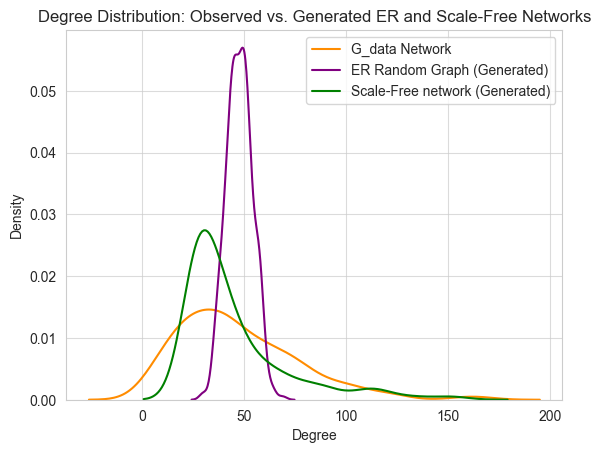

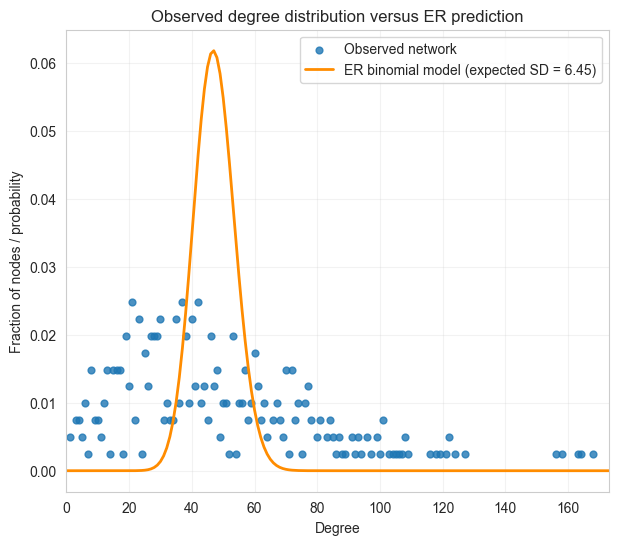

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

observed_degrees = [d for n, d in G.degree()]

# Generate a ER graph
ER_G = nx.erdos_renyi_graph(N, p, seed=SEED)
er_degrees = [d for n, d in ER_G.degree()]

# Genrate Power law graph trhough Barabási-Albert provided by network X
avg_degree = p * (N - 1)
m = int(round(avg_degree / 2))
BA_G = nx.barabasi_albert_graph(N, m, seed=SEED)
ba_degree = [d for n, d in BA_G.degree()]


sns.set_style("whitegrid")

sns.kdeplot(observed_degrees, label="G_data Network", color="darkorange")
sns.kdeplot(er_degrees, label="ER Random Graph (Generated)", color="purple")
sns.kdeplot(ba_degree, label="Scale-Free network (Generated)", color="green")

plt.xlabel("Degree")
plt.ylabel("Density")
plt.title('Degree Distribution: Observed vs. Generated ER and Scale-Free Networks')

plt.legend()
plt.grid(alpha=0.7)

# Second plot
degree_values, counts = np.unique(degrees, return_counts=True)
observed_pmf = counts / N

k = np.arange(N)
er_pmf = binom.pmf(k, N - 1, p)
er_std = np.sqrt((N - 1) * p * (1 - p))

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    degree_values, observed_pmf,
    s=24, alpha=0.8, label="Observed network"
)
ax.plot(
    k, er_pmf,
    color="darkorange", linewidth=2,
    label=f"ER binomial model (expected SD = {er_std:.2f})"
)

ax.set(
    xlabel="Degree",
    ylabel="Fraction of nodes / probability",
    title="Observed degree distribution versus ER prediction",
    xlim=(0, max(degrees) + 5),
)
ax.legend()
ax.grid(alpha=0.25)

print(f"Observed degree SD: {np.std(degrees):.2f}")
print(f"ER expected degree SD: {er_std:.2f}")


> The degree distribution is much broader than expected for an ER graph with the same number of nodes and link density. Its mean degree is about 47.2 and its standard deviation is about 29.9, compared with an expected ER standard deviation of about 6.45. Thus, of the two proposed models, a long-tailed or scale-free model is qualitatively closer with respect to degree spread. A histogram alone does not demonstrate that the degrees follow a power law.

3) What is the degree correlation (assortativity) $\rho_D$? What is its physical meaning?

In [130]:
a = nx.degree_assortativity_coefficient(G)

print(f"Degree corelation: {a}")

Degree corelation: -0.08001195267658665


>The physical meaning of the degree correlation is the tendency of nodes to connect to other nodes with a similar degree. The degree correlation can range between -1 and 1. In this case, we find a degree correlation of ρD = -0.08, which indicates a weak to almost no tendency for nodes with different degrees to connect.

4) What is the clustering coefficient $C$?

In [131]:
C = nx.average_clustering(G)

print(f"Clustering coefficient C: {C}")

Clustering coefficient C: 0.27752342886036674


5) What is the average hopcount $E[H]$ of the shortest paths between all node pairs? What is the diameter $H_max$?

In [132]:
avg_hopcount = nx.average_shortest_path_length(G)

H_max = nx.diameter(G)

#print(nx.is_connected(G))
print(f"Average hopcount C: {avg_hopcount}")
print(f"Diameter: {H_max}")

Average hopcount C: 1.955211535375233
Diameter: 4


6) Has this network the small-world property? Justify your conclusion quantitatively (Hint: Lecture 2).

> According to the lecture, the small-world property is a well-defined concept. A graph has a small-world property if it has a high clustering coefficient and short average path lengths. More concretely, this can be quantified using the small-world coefficient:
>
> $$
> \sigma = \frac{C/C_r}{L/L_r}
> $$
>
> If $\sigma > 1$, with $C > C_r$ and $L \approx L_r$, the network has a small-world property compared to an Erdős–Rényi model with the same average degree. To quantify this, we can generate an Erdős–Rényi random graph with a similar average degree and compare its clustering coefficient and average path length with those of our network.

In [133]:
ERG = nx.erdos_renyi_graph(N,p, seed=SEED)
#C_ERG = nx.average_clustering(ERG) --> C = p in ER graph, no need to simulate 
C_ERG = p
L_ERG = nx.average_shortest_path_length(ERG)

sigma = (C / C_ERG) / (avg_hopcount / L_ERG)

print(f"Small-world coefficient sigma: {sigma}")

print(f"Clustering: {C}")
print(f"Path length: {avg_hopcount}")
print(f"Clustering ER: {C_ERG}")
print(f"Path length ER: {L_ERG}")
#print(f"Is connected: {nx.is_connected(ERG)}")

Small-world coefficient sigma: 2.277657700315567
Clustering: 0.27752342886036674
Path length: 1.955211535375233
Clustering ER: 0.11740305914595756
Path length ER: 1.8839178795847067


> An ER graph has an expected clustering coefficient of $C_r=p=0.1174$, compared with the observed clustering coefficient of $C=0.2775$. Thus, the observed clustering is about $2.37$ times higher than the expected ER value. The simulated ER graph has an average path length of approximately $L_r=1.88$, compared with the observed value of $L=1.95$, meaning that the observed paths are only about $4%$ longer. These values give a small-world coefficient of approximately $\sigma=2.23$. Since $\sigma>1$, this supports the conclusion that the aggregated network has a small-world property according to the criterion stated earlier in the notebook. Because $L_r$ is obtained from a single random ER realization, its value may vary slightly between simulations, and therefore the exact value of $\sigma$ may also differ slightly.

7) Consider further the weight of each link in $G$, which is the total number of contacts between the corresponding two nodes within $[1, T ]$. Plot the probability density function (distribution) of the link weight (Choose the scales of the two axes and the bins/bin-size for the distribution such that the plot is insightful for interpretation).
The probability density function $f_W(x)$ of the weight $W$ of a link is defined as $f_W(x) = \lim_{\Delta x \to 0} \frac{Pr[x < W \le x + \Delta x]}{\Delta x}$,
the probability that the variable (or the percentage of links whose weight) is within each range or bin $(x, x+\Delta x]$ normalized by the size of the bin $\delta x$. Does $W$ follow a power-law distribution? Explain how you arrived atyour conclusion. Hint: All metrics computed for the network $G$ are recommended to put into a table.

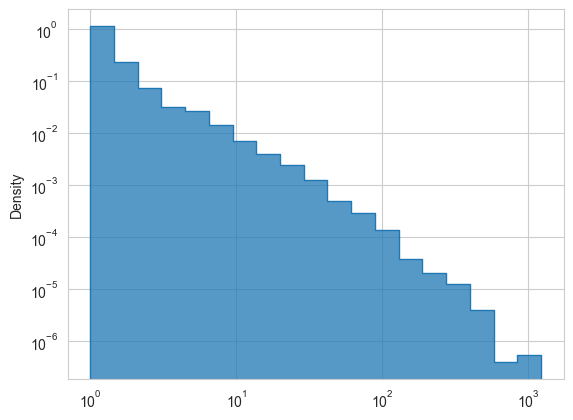

In [134]:
df_data["node_min"] = df_data[["node1", "node2"]].min(axis=1)
df_data["node_max"] = df_data[["node1", "node2"]].max(axis=1)

df_weights = df_data.groupby(["node_min", "node_max"]).size().reset_index(name="weight")

weights = df_weights['weight'].values

bins = np.logspace(np.log10(min(weights)), np.log10(max(weights)), num=20)

sns.histplot(weights, bins=bins, stat="density", element="step")
plt.xscale('log')
plt.yscale('log')





> The link-weight distribution is strongly right-skewed, with most links having a low weight and a small number of links having much higher weights. On the log-log plot, the distribution shows an approximately linear downward trend over a substantial range of link weights. This is consistent with a power-law distribution, since a power law appears approximately linear on a log-log plot. Therefore, the link weights are consistent with a power-law-like distribution. However, the log-log plot alone is not sufficient to prove that the weights follow an exact power law.


**B.**
We consider the following information spreading process, which is actually a simplified Susceptible-Infected
model but on a temporal network. Initially, at time $t = 0$, a single node $s$ is infected meaning that this
node possesses the information whereas all the other nodes are Susceptible, thus have not yet perceived the
information. Node $s$ is also called the seed of the information. Whenever an infected node $i$ is in contact with
a susceptible node $j$ at any time step $t$, the susceptible node becomes infected during the same time step and
could possibly infect other nodes only since the next time step via its contacts with susceptible nodes. Once a
node becomes infected, it stays infected forever. For example, assume that the seed node $s$ has its first contact
at time $t = 5$ and that contact is with node $m$. Although node $s$ gets infected since $t = 0$, it infects a second
node, i.e. node $m$ only at $t = 5$ when it contacts $m$. Infection happens only when an infected node and a
susceptible node are in contact. The number of infected nodes is non-decreasing over time.
Simulate the information spreading process on the given temporal network $G_data$ for $N$ iterations. Each
iteration starts with a different seed node infected at $t = 0$ and ends at $t = T = 3259$ the last time step that
the network is measured. Via the $N$ iterations, we consider the spreading process that starts at every node
$i \in [1, N ]$. Record the total number of infected nodes $I(t)$ at each step $t$ for each iteration.

In [135]:
nodes = pd.concat([df_data["node1"], df_data["node2"]]).unique()

number_nodes = len(nodes)

node_to_index = {node: i for i, node in enumerate(nodes)}   # Mapping of Node to index

df_sorted = df_data.sort_values(by="timestamp")  # Sort so we are sure timesteps are in order

node1_arr = df_sorted["node1"].map(node_to_index).values    # translate node number to index
node2_arr = df_sorted["node2"].map(node_to_index).values   
time_arr = df_sorted["timestamp"].values

timesteps, t_indices = np.unique(time_arr, return_index=True)   #so we have index for every time step

t_indices = np.append(t_indices, len(time_arr)) # prevents out of bounds in our slicing for the last element


I_state = np.eye(number_nodes, dtype=bool)      # Identity matrix with bool for initial condition
infection_counts = np.zeros((len(timesteps),number_nodes), dtype=int)


for i in range(len(timesteps)):
    start_index, end_index = t_indices[i], t_indices[i+1]       # get range of all meetings at that timestep

    node1_t, node2_t = node1_arr[start_index: end_index], node2_arr[start_index: end_index]

    state_n1_to_n2 = I_state[node1_t, :].copy()     # get status of all people in node1
    state_n2_to_n1 = I_state[node2_t, :].copy()     # get status of all people in node2

    np.logical_or.at(I_state, node2_t, state_n1_to_n2)
    np.logical_or.at(I_state, node1_t, state_n2_to_n1)

    infection_counts[i, :] = I_state.sum(axis=0)    # count all 1 along row

infection_counts = np.vstack([np.ones(number_nodes, dtype=int), infection_counts]) # Add initial condition of all nodes infected at t=0
timesteps = np.insert(timesteps, 0, 0)

infection_counts_df = pd.DataFrame(infection_counts, index=timesteps, columns=nodes)
infection_counts_df.index.name = "timestamp"
infection_counts_df.columns.name = "seed_node"

8) Taking all the $N$ iterations into count, plot the average number of infected nodes $E[I(t)]$ together with its error bar standard deviation $\sqrt{Var[I(t)]}$ as a function of the time step $t$.

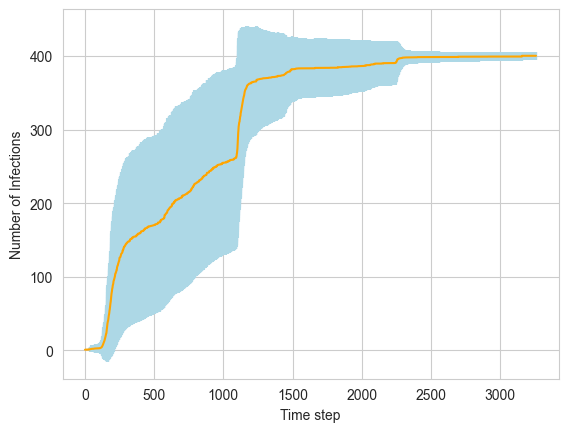

In [136]:
mean_infections = infection_counts_df.mean(axis=1)
std_infetions = infection_counts_df.std(axis=1, ddof=0)

plt.xlabel("Time step")
plt.ylabel("Number of Infections")
plt.errorbar(timesteps, mean_infections, yerr=std_infetions, color="orange", ecolor="lightblue")
plt.show()

> The average number of infected nodes increases over time, as expected: infected nodes remain infected and can pass the information on through later contacts. The error bars show that the outcome depends on the initial seed, especially during the earlier stages of the spreading process. By the final time step, the average is about 400 of the 403 nodes.

9) How influential a node is as a seed node could be quantified by the total number of nodes that have been
infected by a specific time $t^{(l)} = 1200$ when that node is the sole seed node. This total number of infected nodes
at $t^{(l)} = 1200$ is also called the influence of that node. Plot the influence of every node in descending order.
Rank all nodes by influence and store the ranking in a vector $R = [R(1) , R(2) , ..., R(N ) ]$ where $R(i)$ represents the
index of the i-th most influential node and $R_{(1)}$ is the most influential node. (Note: you don’t need to include
this vector in your report.)

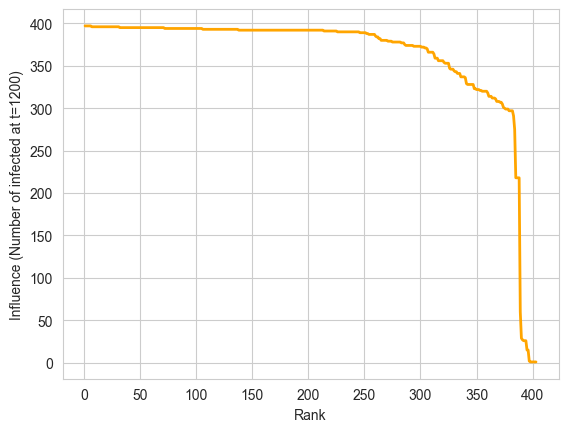

In [137]:
influence_at_1200 = infection_counts_df.loc[1200]

sorted_influences = influence_at_1200.sort_values(ascending=False)

R = sorted_influences.index.values

ranks = range(1, len(sorted_influences) + 1)

sns.lineplot(x=ranks, y=sorted_influences.values, color="orange", linewidth=2)

plt.xlabel("Rank")
plt.ylabel("Influence (Number of infected at t=1200)")
plt.show()



We will explore which nodal level network feature (centrality metric) in network $G_{data}$ better predicts nodal influence described above. First, compute the total number of unique nodes that each node $i$ has contacted during the time interval $[1, t^{(l)}]$. This is equivalent to the degree $d^{t^{(l)}}_i$ of node $i$ in the aggregated network which is formed by aggregating the temporal network $G_{data}$ over $[1, t^{(l)}]$. Based on this centrality metric derived for every node, construct the ordered vector $D = [D_{(1)} , D_{(2)}, ..., D_{(N)}]$, where $D_{(i)}$ is the node index with the $i − th$
highest degree in this aggregated network over $[1, t^{(l)}]$. How precisely a centrality metric (such as node degree in an aggregated network) predicts the ranking of nodes by influence could be quantified by the top $f$ recognition rate $r_{RD}(f) = \cfrac{|R_f \cap D_f|}{|R_f|}$ where $R_f$ and $D_f$ are the sets of nodes ranking in the top $f$ fraction according to influence and degree (in aggregated network) respectively and $|R_f| = fN$ is the number of nodes in $R_f$.



(a) Plot $r_{RD}(f)$ as a function of $f$ for $f = 0.05, 0.1, 0.15, ..., 0.5$.

Note on ties: It is possible that multiple nodes may share the same rank, the selection of $R_f$ or $D_f$ may not be unique. In such case, $r_{RD}(f)$ must be computed as the average of 1000 iterations. In each iteration, $R_f$ and $D_f$ are sampled independently and uniformly at random from their corresponding possible choices and further
used to compute the recognition rate. (This randomized tie-breaking procedure applies to all recognition rate calculations in this assignment.) Consider the degree sequence $d^{t^{(l)}}_1 = 3, d^{t^{(l)}}_2 = 1, d^{t^{(l)}}_3 = 1, {d^{t^{(l)}}_4 = 1}$ as an example. $D_{f=0.5} =0.5$ (top 2 nodes) has three possible choices ${1, 2}, {1, 3}$ and ${1, 4}$. A random choice $D_{f=0.5}$ from possible sets could also be obtained by firstly choosing the rank of nodes $2, 3$ and $4$ by degree as a randomized/reshuffled vector of $[2, 3, 4]$ since node $1$ has rank $1$ and afterwards selecting the $2$ nodes out of the $4$ with the highest rank.

Similarly, compute the degree $d^{t^s}_i$ of each node $i$ in the aggregated network formed by aggregating $G_{data}$ over $[1, t^s]$, where $t^s = 600$. Metric $d^{t^s}_i$ could also be used to estimate the ranking of nodes by influence. Construct the corresponding ordered vector $D' = [D'_{(1)}, D'_{(2)}, ..., D'_{(N)}]$, where $D'_{(i)}$ is the node index with the $i−th$ highest degree in the aggregated network over $[1, t^{(1)}]$.

(b) Plot $r_{RD'}(f)$ as a function of $f$ for $f = 0.05, 0.1, 0.15, ..., 0.5$.

Consider a third nodal property: the time $Z_i$ when node $i$ makes its first contact in network $D_{data}$ . Construct the ordered vector $Z = [Z_{(1)}, Z_{(2)}, ..., Z_{(N)}]$, where $Z_{(i)}$ is the node index with the $i−th$ shortest time to make its first contact and use $Z$ to predict nodes’ ranking by influence.

(c) Plot the recognition rate $r_{RZ}(f)$ as a
function of $f$ for $f = 0.05, 0.1, 0.15, ..., 0.5$.

Plot the recognition rates obtained in (a), (b), and (c) on a single
figure for direct comparison.

## Code for 9a-c

In [145]:
# Influence at t = 1200, indexed by seed-node ID
influence = infection_counts_df.loc[1200].reindex(nodes)

# Include every node in both aggregated graphs, even if it had
# no contacts during the specified interval.
def degrees_up_to(t):
    contacts = df_data[df_data["timestamp"] <= t]

    graph = nx.from_pandas_edgelist(
        contacts, source="node1", target="node2"
    )
    graph.add_nodes_from(nodes)

    return pd.Series(dict(graph.degree())).reindex(nodes)

degree_1200 = degrees_up_to(1200)  # D: question 9(a)
degree_600 = degrees_up_to(600)    # D': question 9(b)

# First contact of each node, whether it occurs in node1 or node2
first_as_node1 = df_data.groupby("node1")["timestamp"].min()
first_as_node2 = df_data.groupby("node2")["timestamp"].min()

first_contact = pd.concat(
    [first_as_node1, first_as_node2], axis=1
).min(axis=1).reindex(nodes)       # Z: question 9(c)

# These are the requested ordered vectors. Their order within
# tied groups is arbitrary; recognition rates below resolve ties
# separately by random sampling.
D = degree_1200.sort_values(ascending=False).index.to_numpy()
D_prime = degree_600.sort_values(ascending=False).index.to_numpy()
Z = first_contact.sort_values(ascending=True).index.to_numpy()

,Degree through t=1200,Degree through t=600,First-contact time
Top fraction f,,,
0.05,0.239000,0.398000,0.637000
0.10,0.350150,0.447400,0.672525
0.15,0.457700,0.512517,0.676767
0.20,0.515198,0.541864,0.761222
0.25,0.576000,0.589129,0.834267
0.30,0.548091,0.598612,0.859512
0.35,0.545071,0.648113,0.899333
0.40,0.583149,0.715894,0.881994
0.45,0.634740,0.753569,0.869403


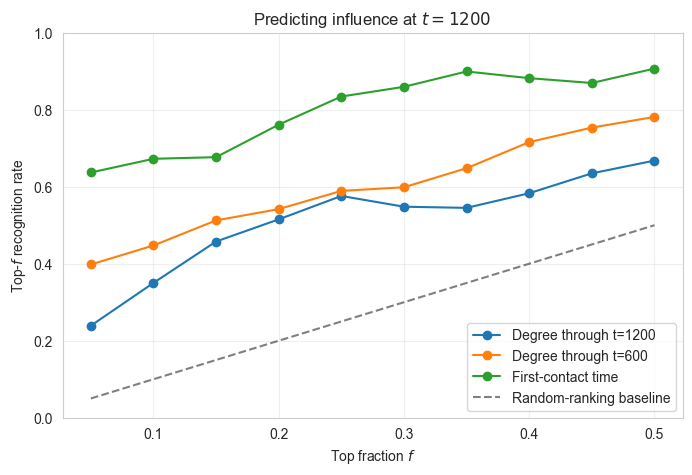

In [139]:
rng = np.random.default_rng(SEED)

def sample_top_nodes(scores, k, highest=True):
    """Sample a top-k set, breaking boundary ties uniformly at random."""
    values = scores.to_numpy()

    if highest:
        cutoff = np.sort(values)[-k]
        definite = scores.index[values > cutoff].to_numpy()
    else:
        cutoff = np.sort(values)[k - 1]
        definite = scores.index[values < cutoff].to_numpy()

    tied = scores.index[values == cutoff].to_numpy()
    number_needed = k - len(definite)

    chosen_ties = rng.choice(
        tied, size=number_needed, replace=False
    )
    return set(definite) | set(chosen_ties)


fractions = np.arange(1, 11) * 0.05
predictors = {
    "Degree through t=1200": (degree_1200, True),
    "Degree through t=600": (degree_600, True),
    "First-contact time": (first_contact, False),
}

recognition_rates = {}

for label, (scores, highest) in predictors.items():
    rates = []

    for f in fractions:
        # With N=403, f*N is generally not an integer.
        k = round(f * len(nodes))

        trial_rates = []
        for _ in range(1000):
            R_f = sample_top_nodes(influence, k, highest=True)
            predictor_f = sample_top_nodes(scores, k, highest=highest)

            trial_rates.append(len(R_f & predictor_f) / k)

        rates.append(np.mean(trial_rates))

    recognition_rates[label] = rates

recognition_df = pd.DataFrame(recognition_rates, index=fractions)
recognition_df.index.name = "Top fraction f"

display(recognition_df)

ax = recognition_df.plot(marker="o", figsize=(8, 5))
ax.plot(
    fractions, fractions, "k--", alpha=0.5,
    label="Random-ranking baseline"
)
ax.set(
    xlabel="Top fraction $f$",
    ylabel="Top-$f$ recognition rate",
    title="Predicting influence at $t=1200$",
    ylim=(0, 1),
)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

(d) Which centrality metric $d^t_i$, $d^{t^l}_i$ or $Z_i$ best predict the ranking of nodes by influence and which performs the worst? Why?

> The first-contact time \(Z_i\) predicts influence best across the plotted fractions. Nodes that make their first contact earlier have more time for information to spread through subsequent contacts before \(t=1200\). Degree up to \(t=600\) generally predicts influence better than degree up to \(t=1200\), because it uses information about a node early enough to leave more time for the spreading process. Degree up to \(t=1200\) performs worst of the three metrics. This suggests that, for this temporal spreading process, the timing of contacts is important in predicting influence, not only the number of unique contacts a node has.

10) The short-term influence of a node $i$ is defined as the total number of nodes that have been infected at $t^{(s)} = 600$ when node $i$ is the single seed node. Rank nodes by their short-term influence and record the ranking in a vector $R' = [R'_{(1)}, R'_{(2)}, ...,R'_{(N)}]$ where $R'_{(i)}$ is the index of the node with the $i - th$ highest short-term
influence. This short-term influence can also be used to estimate the influence (long-term) defined in 9). Plot the recognition rate $r_{RR'}(f)$ as a function of $f$ in the same figure as in question (9). Can this short-term influence better predict (long-term) influence in ranking than those three centrality metrics studied in 9)? Why?

,Degree through t=1200,Degree through t=600,First-contact time,Short-term influence (t=600)
Top fraction f,,,,
0.05,0.239000,0.398000,0.637000,0.691500
0.10,0.350150,0.447400,0.672525,0.774900
0.15,0.457700,0.512517,0.676767,0.812467
0.20,0.515198,0.541864,0.761222,0.860160
0.25,0.576000,0.589129,0.834267,0.964198
0.30,0.548091,0.598612,0.859512,0.916967
0.35,0.545071,0.648113,0.899333,0.929184
0.40,0.583149,0.715894,0.881994,0.885870
0.45,0.634740,0.753569,0.869403,0.896409


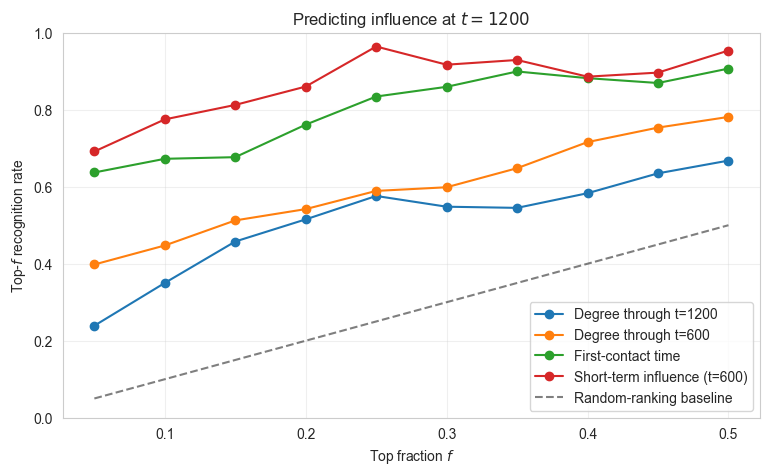

In [146]:
# R': number infected by t=600 for each seed
short_influence = infection_counts_df.loc[600].reindex(nodes)

# Store the requested ranking vector. Ties have an arbitrary order here;
# sample_top_nodes handles them randomly for the recognition rates.
R_prime = short_influence.sort_values(ascending=False).index.to_numpy()

short_term_rates = []

for f in fractions:
    k = round(f * len(nodes))
    trial_rates = []

    for _ in range(1000):
        # Draw the two top-f sets independently, including tie-breaking
        R_f = sample_top_nodes(influence, k, highest=True)
        R_prime_f = sample_top_nodes(short_influence, k, highest=True)

        trial_rates.append(len(R_f & R_prime_f) / k)

    short_term_rates.append(np.mean(trial_rates))

recognition_df["Short-term influence (t=600)"] = short_term_rates

display(recognition_df)

# Replace the earlier question 9 figure with this combined figure.
ax = recognition_df.plot(marker="o", figsize=(9, 5))
ax.plot(
    fractions, fractions, "k--", alpha=0.5,
    label="Random-ranking baseline"
)
ax.set(
    xlabel="Top fraction $f$",
    ylabel="Top-$f$ recognition rate",
    title="Predicting influence at $t=1200$",
    ylim=(0, 1),
)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

> Short-term influence at \(t=600\) generally predicts the ranking of influence at \(t=1200\) better than the three individual node properties in question 9. It already measures the outcome of information spreading during the first 600 time steps, taking into account both the timing of contacts and the chains of contacts that can be reached from each seed. Degree only counts distinct contacts and does not describe these spreading chains, while first-contact time only describes when a node first enters the contact network. Therefore, nodes that spread information widely by \(t=600\) tend to also be influential at \(t=1200\), although their rankings can still change as additional contacts occur.

11) Another temporal network $G_2$ is given the attachment and is obtained as follows. $G2$ is $G_{data}$ where the time stamps describing when each temporal link (contact) appears in $G_data$ are randomized. In other words, $G_2$ is constructed by copying all the temporal links ${(a, b, t)}$ from $G_{data}$ but their time stamps $t$ are randomly re-shuffled. The number of contacts between each node pair remains the same between $G_{data}$ and $G_2$. Now, perform the same analysis in 8)-10) for $G_2$ .In this case, the spreading process unfolds on $G_2$ and all centrality metrics and nodal influences are to be derived from $G_2$.

In [141]:
df_g2 = pd.read_excel("G_2.xlsx")

# Use the same seed-node set and column order as for G_data.
nodes_g2 = pd.concat([df_g2["node1"], df_g2["node2"]]).unique()
assert set(nodes_g2) == set(nodes)
assert df_g2["timestamp"].max() == 3259

def simulate_all_seeds(contacts, node_order, T=3259):
    node_order = np.asarray(node_order)
    node_to_index = {
        node: i for i, node in enumerate(node_order)
    }

    ordered = contacts.sort_values("timestamp")
    times = ordered["timestamp"].to_numpy()
    source = ordered["node1"].map(node_to_index).to_numpy()
    target = ordered["node2"].map(node_to_index).to_numpy()

    # Row = person who may become infected; column = initial seed.
    infected = np.eye(len(node_order), dtype=bool)

    # Include t=0 to display the stated initial condition.
    counts = np.empty((T + 1, len(node_order)), dtype=int)
    counts[0] = 1

    for t in range(1, T + 1):
        start = np.searchsorted(times, t, side="left")
        end = np.searchsorted(times, t, side="right")

        a = source[start:end]
        b = target[start:end]

        # Capture states BEFORE any contacts at this time step.
        state_a = infected[a, :].copy()
        state_b = infected[b, :].copy()

        np.logical_or.at(infected, b, state_a)
        np.logical_or.at(infected, a, state_b)

        counts[t] = infected.sum(axis=0)

    return pd.DataFrame(
        counts,
        index=pd.Index(range(T + 1), name="timestamp"),
        columns=pd.Index(node_order, name="seed_node"),
    )

infection_counts_g2 = simulate_all_seeds(df_g2, nodes)

a) Similar to question 8), plot the average number of infected nodes $E[I(t)]$ together with its error bar (standard deviation $\sqrt{Var[I(t)]}$ as a function of the time step $t$ for network $G_2$. Compare this result obtained from $G_2$ with your answer to 8) derived from $G_{data}$. What is the key difference? Please explain it.

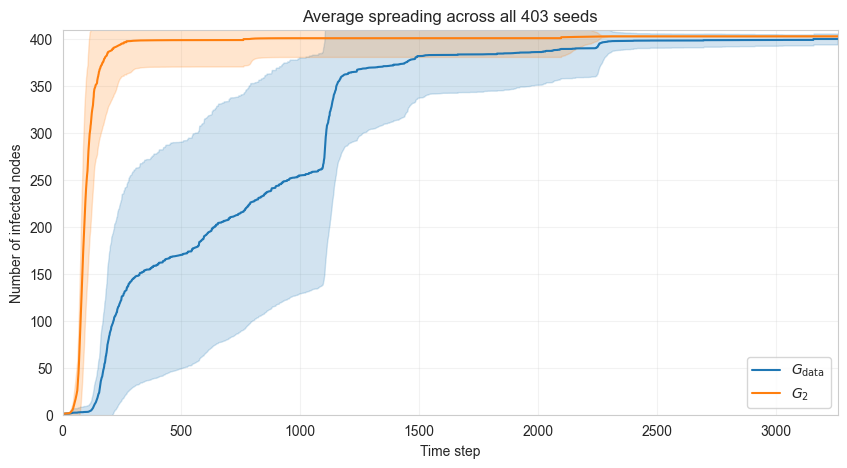

In [147]:
# G_data's existing dataframe starts at t=1; add its known t=0 state.
# counts_data = infection_counts_df.reindex(range(3260))
# counts_data.loc[0] = 1
# Code above not needed, fixed in Q8
counts_data = infection_counts_df.copy()
counts_data = counts_data.sort_index()

fig, ax = plt.subplots(figsize=(10, 5))

for counts, label, color in [
    (counts_data, r"$G_{\mathrm{data}}$", "tab:blue"),
    (infection_counts_g2, r"$G_2$", "tab:orange"),
]:
    mean = counts.mean(axis=1)
    std = counts.std(axis=1, ddof=0)

    # Gemiddelde spreading
    ax.plot(
        mean.index,
        mean,
        color=color,
        label=label
    )

    # Standard-deviation area
    ax.fill_between(
        mean.index,
        mean - std,
        mean + std,
        color=color,
        alpha=0.2
    )

ax.set(
    xlabel="Time step",
    ylabel="Number of infected nodes",
    title="Average spreading across all 403 seeds",
    xlim=(0, 3259),
    ylim=(0, 410),
)

ax.legend()
ax.grid(alpha=0.25)
plt.show()

> Information spreads substantially faster in \(G_2\). At \(t=200\), the average number infected is about 387 in \(G_2\), compared with 88 in \(G_{\mathrm{data}}\); by \(t=600\), the averages are about 399 and 191, respectively. The timestamp shuffle preserves the number of contacts between each node pair, but changes when these contacts occur. In the original data, the timing of contacts can constrain the available time-respecting paths. After reshuffling, the different temporal order can create routes through which an infection can reach other parts of the network much earlier. The variation between seeds consequently falls sooner in \(G_2\), and all 403 seeds reach all 403 nodes by the final time step.


b) Similary to 9) and 10), plot $r_{RD}(f), r_{RD'}(f), r_{RZ}(f)$ and $r_{RR'}(f)$ respectively for $G_2$ as a function of $f$. Compare your results here obtained from $G_2$ and answers to 9) and 10) obtained from $G_{data}$. What is the key difference? Explain the key difference.

Note: Questions asking ’why’ or requesting explanations refer specifically to the causes behind your observations.

In [143]:
# Influence rankings in G_2
influence_g2 = infection_counts_g2.loc[1200].reindex(nodes)
short_influence_g2 = infection_counts_g2.loc[600].reindex(nodes)

def g2_degrees_up_to(t):
    graph = nx.from_pandas_edgelist(
        df_g2[df_g2["timestamp"] <= t],
        source="node1",
        target="node2",
    )
    graph.add_nodes_from(nodes)
    return pd.Series(dict(graph.degree())).reindex(nodes)

degree_1200_g2 = g2_degrees_up_to(1200)
degree_600_g2 = g2_degrees_up_to(600)

first_as_node1_g2 = df_g2.groupby("node1")["timestamp"].min()
first_as_node2_g2 = df_g2.groupby("node2")["timestamp"].min()
first_contact_g2 = pd.concat(
    [first_as_node1_g2, first_as_node2_g2], axis=1
).min(axis=1).reindex(nodes)

predictors_g2 = {
    "Degree through t=1200": (degree_1200_g2, True),
    "Degree through t=600": (degree_600_g2, True),
    "First-contact time": (first_contact_g2, False),
    "Short-term influence (t=600)": (short_influence_g2, True),
}

# sample_top_nodes uses the notebook's rng. Reset it here so this
# calculation is reproducible if the cell is run again.
rng = np.random.default_rng(SEED + 11)

recognition_g2 = {}

for label, (scores, highest) in predictors_g2.items():
    rates = []

    for f in fractions:
        k = round(f * len(nodes))
        trials = []

        for _ in range(1000):
            R_f = sample_top_nodes(
                influence_g2, k, highest=True
            )
            predictor_f = sample_top_nodes(
                scores, k, highest=highest
            )
            trials.append(len(R_f & predictor_f) / k)

        rates.append(np.mean(trials))

    recognition_g2[label] = rates

recognition_g2_df = pd.DataFrame(
    recognition_g2,
    index=pd.Index(fractions, name="Top fraction f"),
)

display(recognition_g2_df)
print("G_2 influence at t=1200:")
display(influence_g2.value_counts().sort_index())

,Degree through t=1200,Degree through t=600,First-contact time,Short-term influence (t=600)
Top fraction f,,,,
0.05,0.050050,0.051700,0.049100,0.049650
0.10,0.098525,0.101250,0.099575,0.098500
0.15,0.149217,0.150917,0.149600,0.148750
0.20,0.201469,0.201099,0.200556,0.204630
0.25,0.250792,0.253188,0.251624,0.251495
0.30,0.302661,0.301471,0.302355,0.301934
0.35,0.350582,0.351674,0.351099,0.350248
0.40,0.402317,0.403876,0.401329,0.401099
0.45,0.449751,0.451735,0.450674,0.451597


G_2 influence at t=1200:


1200
1        1
401      1
402    401
Name: count, dtype: int64

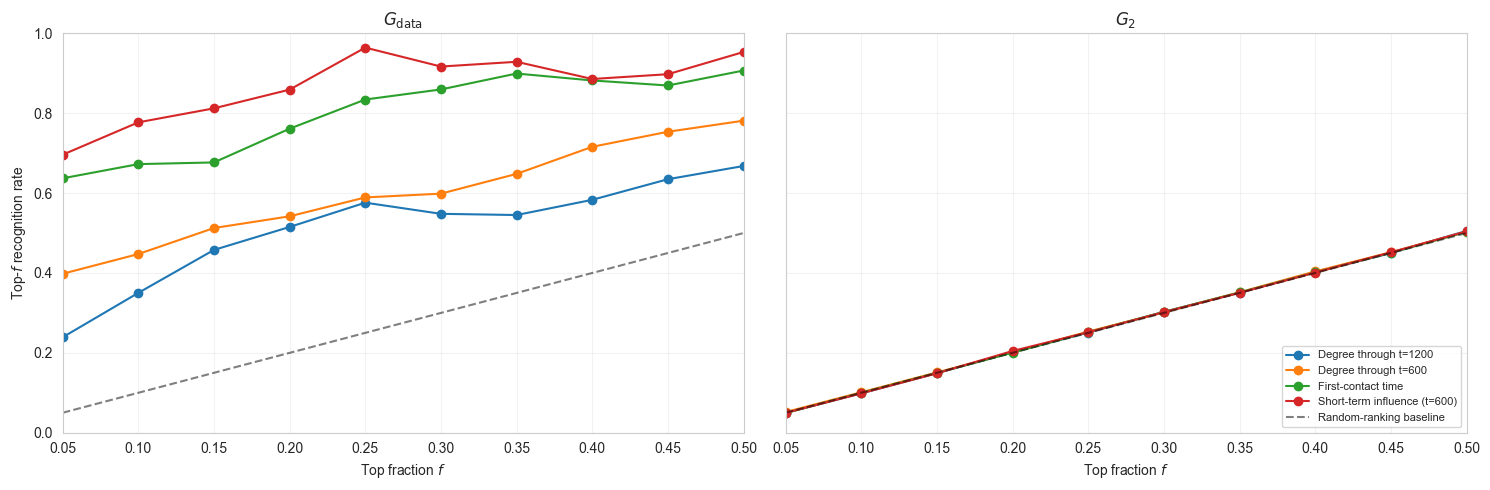

In [144]:
fig, axes = plt.subplots(
    1, 2, figsize=(15, 5), sharex=True, sharey=True
)

for ax, table, title in [
    (axes[0], recognition_df, r"$G_{\mathrm{data}}$"),
    (axes[1], recognition_g2_df, r"$G_2$"),
]:
    for label in predictors_g2:
        ax.plot(
            table.index,
            table[label],
            marker="o",
            label=label,
        )

    ax.plot(
        fractions, fractions, "k--",
        alpha=0.5, label="Random-ranking baseline"
    )
    ax.set(
        title=title,
        xlabel="Top fraction $f$",
        xlim=(0.05, 0.5),
        ylim=(0, 1),
    )
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Top-$f$ recognition rate")
axes[1].legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

> The four recognition rates for \(G_2\) are close to the random-ranking baseline \(r=f\), whereas the corresponding curves for \(G_{\mathrm{data}}\) are substantially higher. The main reason is that spreading is much faster in \(G_2\). At \(t=1200\), 401 of the 403 seeds infect exactly 402 nodes. Therefore, many nodes have the same influence score, so the top-\(f\) influential nodes are largely determined by random tie-breaking. This makes the overlap with the predictor rankings close to the random expectation. The timestamp shuffle creates time-respecting paths earlier, causing the spreading process to reach almost the whole network before \(t=1200\). As a result, there is very little variation in influence at \(t=1200\), making it difficult for the centrality measures to predict the influence ranking.
